In [2]:
import json, pandas as pd, numpy as np
from pathlib import Path

with open('data/raw/finagent_config.json') as f:
    cfg = json.load(f)
TICKERS     = cfg['TICKERS']
MACRO       = cfg['MACRO']
ALL_SYMBOLS = cfg['ALL_SYMBOLS']
PERIOD      = cfg['PERIOD']

# Load clean price data
clean_dfs = {}
for symbol in ALL_SYMBOLS:
    safe = symbol.replace('=','_')
    path = f'data/processed/{safe}_clean.csv'
    if Path(path).exists():
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        clean_dfs[symbol] = df
        print(f'  ✅ {symbol:10} loaded')
    else:
        print(f'  ⚠️  Missing: {path} — chạy Module 2 trước')

# Load supplemental data
def load_csv(path, index_col=0):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p, index_col=0, parse_dates=True,date_format='%Y-%m-%d')
    print(f'  ⚠️  Missing: {path}')
    return None

fund_df  = load_csv('data/processed/fundamentals.csv', index_col=0)
macro_df = load_csv('data/processed/macro_fred.csv',index_col=0)

print(f'\n✅ {len(clean_dfs)} price datasets ready')

  ✅ AAPL       loaded
  ✅ MSFT       loaded
  ✅ NVDA       loaded
  ✅ GOOG       loaded
  ✅ GC=F       loaded
  ✅ CL=F       loaded

✅ 6 price datasets ready


In [3]:
# ── Chart setup ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4']
DPI = 130
Path('outputs/charts').mkdir(parents=True, exist_ok=True)
print('✅ Chart config ready')

✅ Chart config ready


In [19]:
# !pip install plotly

# Chart 1: Price trend & Volume

In [20]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Khởi tạo subplots: n tickers, mỗi ticker 2 hàng (Price & Volume)
n = len(TICKERS)
fig = make_subplots(rows=n*2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.02,
                    row_heights=[0.7, 0.3] * n,
                    subplot_titles=[f"{t} — Price & Volume" for t in TICKERS for _ in range(2)][::2])

for i, ticker in enumerate(TICKERS):
    if ticker not in clean_dfs: continue
    df = clean_dfs[ticker].dropna(subset=['Close'])
    r_p, r_v = i*2 + 1, i*2 + 2 # Vị trí hàng cho Price và Volume
    
    # --- Biểu đồ Giá (Price) ---
    fig.add_trace(go.Scatter(x=df.index, y=df['Close'], name=f'{ticker} Close', line=dict(width=1.5)), row=r_p, col=1)
    if 'MA_7' in df.columns:
        fig.add_trace(go.Scatter(x=df.index, y=df['MA_7'], name='MA 7', line=dict(dash='dash', color='orange')), row=r_p, col=1)
    if 'MA_30' in df.columns:
        fig.add_trace(go.Scatter(x=df.index, y=df['MA_30'], name='MA 30', line=dict(dash='dot', color='red')), row=r_p, col=1)

    # --- Biểu đồ Khối lượng (Volume) ---
    colors = ['#4CAF50' if r >= 0 else '#F44336' for r in df['Daily_Return'].fillna(0)]
    fig.add_trace(go.Bar(x=df.index, y=df['Volume'], marker_color=colors, name=f'{ticker} Vol', opacity=0.6), row=r_v, col=1)

    # --- Định dạng trục Y ---
    fig.update_yaxes(title_text="Price (USD)", tickformat="$,.0f", row=r_p, col=1)
    fig.update_yaxes(title_text="Vol", tickformat=".2s", row=r_v, col=1) # .2s tự động đổi sang M, k...

# 2. Cấu hình giao diện chung
fig.update_layout(
    height=400*n,
    title=dict(
        text='<b>Stock Prices with Volume Overlay</b>',
        x=0.5,
        xanchor='center',
        font=dict(size=16),
    ),
    showlegend=False,
    hovermode='x unified',
    template='plotly_white',
)
fig.update_xaxes(rangeslider_visible=False) # Tắt slider để nhìn gọn hơn

fig.show()

fig.write_image("outputs/charts/chart1_price_volume.png", scale=2)
print('✅ Saved: outputs/charts/chart1_price_volume.png')

✅ Saved: outputs/charts/chart1_price_volume.png


In [4]:
import plotly.graph_objects as go

fig = go.Figure()

for i, ticker in enumerate(TICKERS):
    if ticker not in clean_dfs:
        continue
    df = clean_dfs[ticker].dropna(subset=['Close'])

    # Normalize to 100 at first data point
    normalized = (df['Close'] / df['Close'].iloc[0]) * 100

    fig.add_trace(go.Scatter(
        x=df.index,
        y=normalized,
        name=ticker,
        mode='lines',
        line=dict(width=1.8),
        hovertemplate='%{x|%b %Y}<br>' + ticker + ': %{y:.1f}<extra></extra>',
    ))

# Reference line at 100
fig.add_hline(
    y=100,
    line_dash='dash',
    line_color='grey',
    line_width=0.8,
    opacity=0.5,
)

fig.update_layout(
    title=dict(
        text='<b>Cumulative Performance (Normalized to 100)</b>',
        x=0.5,
        xanchor='center',
        font=dict(size=16),
    ),
    template='plotly_white',
    height=500,
    hovermode='x unified',
    yaxis=dict(
        title='Indexed Return (Base = 100)',
        tickformat=',.0f',
    ),
    legend=dict(
        orientation='h',
        y=1.02, x=0.5, xanchor='center',
        font=dict(size=11),
        bgcolor='rgba(255,255,255,0.8)',
    ),
    margin=dict(l=60, r=30, t=80, b=40),
)
fig.update_xaxes(rangeslider_visible=False)

fig.show()

fig.write_html('outputs/charts/chart1_performance.html', include_plotlyjs='cdn')
try:
    fig.write_image('outputs/charts/chart1_performance.png', scale=2)
    print('✅ Saved: outputs/charts/chart1_performance.png')
except Exception as e:
    print(f'ℹ️  PNG skipped: {e}')

✅ Saved: outputs/charts/chart1_performance.png


# Chart 2: Heatmap

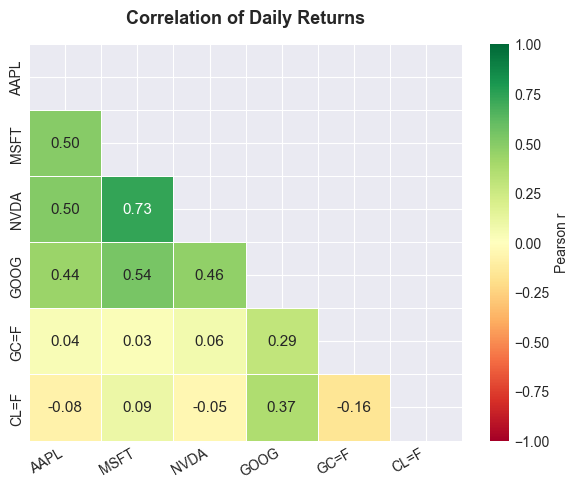

In [21]:
returns_df = pd.DataFrame({
    sym: clean_dfs[sym]['Daily_Return'] for sym in ALL_SYMBOLS if sym in clean_dfs
}).dropna()
corr = returns_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(max(6,len(corr)), max(5,len(corr)-1)))
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            linewidths=0.5, cbar_kws={'label':'Pearson r'}, annot_kws={'size':11})
ax.set_title('Correlation of Daily Returns', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
fig.savefig('outputs/charts/chart2_correlation_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()

# Chart 3: Return distribution

In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import numpy as np

PALETTE_HEX = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4']

# ── Layout subplots ───────────────────────────────────────────────────
n      = len(TICKERS)
cols_n = min(2, n)
rows_n = (n + cols_n - 1) // cols_n

fig = make_subplots(
    rows=rows_n, cols=cols_n,
    subplot_titles=[f'{t} — Daily Return Distribution' for t in TICKERS],
    horizontal_spacing=0.10,
    vertical_spacing=0.12,
)

for i, ticker in enumerate(TICKERS):
    if ticker not in clean_dfs:
        continue

    row = i // cols_n + 1
    col = i %  cols_n + 1
    color_hex = PALETTE_HEX[i % len(PALETTE_HEX)]

    returns = clean_dfs[ticker]['Daily_Return'].dropna() * 100
    mu      = returns.mean()
    sigma   = returns.std()
    skew    = returns.skew()
    kurt    = returns.kurtosis()

    # ── Histogram (density) ───────────────────────────────────────────
    counts, bin_edges = np.histogram(returns, bins=50, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]

    fig.add_trace(go.Bar(
        x=bin_centers,
        y=counts,
        width=bin_width,
        name=ticker,
        marker=dict(color=color_hex, opacity=0.45, line=dict(width=0)),
        hovertemplate=(
            'Return: %{x:.3f}%<br>'
            'Density: %{y:.4f}<extra></extra>'
        ),
        showlegend=True,
        legendgroup=ticker,
    ), row=row, col=col)

    # ── KDE curve ────────────────────────────────────────────────────
    kde_x = np.linspace(returns.min(), returns.max(), 300)
    kde_y = stats.gaussian_kde(returns)(kde_x)

    fig.add_trace(go.Scatter(
        x=kde_x, y=kde_y,
        mode='lines',
        name=f'{ticker} KDE',
        line=dict(color=color_hex, width=2),
        hovertemplate='Return: %{x:.3f}%<br>KDE: %{y:.4f}<extra></extra>',
        showlegend=False,
        legendgroup=ticker,
    ), row=row, col=col)

    # ── Đường dọc: mean, ±1σ, zero ───────────────────────────────────
    vlines = [
        (mu,         'black',  'dash',  f'μ = {mu:.3f}%'),
        (mu + sigma, '#666',   'dot',   f'+1σ = {mu+sigma:.3f}%'),
        (mu - sigma, '#666',   'dot',   f'−1σ = {mu-sigma:.3f}%'),
        (0,          '#e53935','solid', 'Zero'),
    ]
    for xv, clr, dash, label in vlines:
        fig.add_vline(
            x=xv, line_dash=dash, line_color=clr,
            line_width=1.2 if clr != '#e53935' else 0.9,
            opacity=0.85 if clr == 'black' else 0.6,
            row=row, col=col,
        )

    # ── Stats annotation (góc trên phải mỗi subplot) ─────────────────
    stats_text = (
        f'<b>μ</b>  = {mu:.3f}%<br>'
        f'<b>σ</b>  = {sigma:.3f}%<br>'
        f'<b>Sk</b> = {skew:.2f}<br>'
        f'<b>Ku</b> = {kurt:.2f}'
    )
    # Tính toạ độ paper cho annotation theo subplot
    # x_paper: col=1 → [0, 0.45], col=2 → [0.55, 1.0]  (spacing=0.10)
    x0 = (col - 1) / cols_n + (0.10 / 2 if col > 1 else 0)
    x1 = col       / cols_n - (0.10 / 2 if col < cols_n else 0)
    y0 = 1 - (row - 1) / rows_n - (0.12 / 2 if row > 1 else 0)
    y1 = 1 - row       / rows_n + (0.12 / 2 if row < rows_n else 0)

    fig.add_annotation(
        text=stats_text,
        xref='paper', yref='paper',
        x=x1 - 0.01,
        y=y0 - 0.02,
        xanchor='right', yanchor='top',
        align='left',
        showarrow=False,
        bgcolor='rgba(255,255,255,0.80)',
        bordercolor='#ccc',
        borderwidth=0.8,
        borderpad=5,
        font=dict(size=10, family='monospace'),
    )

    # ── Axis labels ───────────────────────────────────────────────────
    axis_idx = '' if (row == 1 and col == 1) else str(i + 1)
    fig.update_xaxes(title_text='Daily Return (%)',
                     ticksuffix='%', row=row, col=col)
    fig.update_yaxes(title_text='Density', row=row, col=col)

# ── Ẩn subplot trống (nếu n lẻ) ──────────────────────────────────────
if n % cols_n != 0:
    fig.update_xaxes(visible=False, row=rows_n, col=cols_n)
    fig.update_yaxes(visible=False, row=rows_n, col=cols_n)

# ── Global layout ─────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='<b>Daily Return Distributions</b>',
        font=dict(size=16, color='#222'),
        x=0.5,
        xanchor='center',
    ),
    template='plotly_white',
    height=420 * rows_n,
    bargap=0,
    legend=dict(
        orientation='h',
        y=-0.06,
        x=0.5,
        xanchor='center',
        font=dict(size=11),
    ),
    hoverlabel=dict(bgcolor='white', font_size=11),
    margin=dict(l=55, r=30, t=70, b=60),
)

fig.update_annotations(font_size=11)   # subplot titles

# ── Save ──────────────────────────────────────────────────────────────
out_html = 'outputs/charts/chart3_return_distributions.html'
fig.write_html(out_html, include_plotlyjs='cdn')
print(f'✅ Saved interactive: {out_html}')

try:
    fig.write_image('outputs/charts/chart3_return_distributions.png', scale=2)
    print('✅ Saved static PNG')
except Exception as e:
    print(f'ℹ️  PNG skipped: {e}')

fig.show()

✅ Saved interactive: outputs/charts/chart3_return_distributions.html
✅ Saved static PNG


# Chart 4: Bollinger Bands + MACD + RSI

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PALETTE_HEX = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4']

for i, ticker in enumerate(TICKERS):
    if ticker not in clean_dfs:
        continue

    df    = clean_dfs[ticker].dropna(subset=['Close'])
    color = PALETTE_HEX[i % len(PALETTE_HEX)]

    has_bb   = 'BB_Upper' in df.columns and 'BB_Lower' in df.columns
    has_ma7  = 'MA_7'     in df.columns
    has_ma30 = 'MA_30'    in df.columns
    has_macd = 'MACD'     in df.columns and 'MACD_Signal' in df.columns
    has_rsi  = 'RSI_14'   in df.columns

    # ── Subplots: Price / MACD / RSI ─────────────────────────────────
    fig = make_subplots(
        rows=3, cols=1,
        shared_xaxes=True,
        row_heights=[0.55, 0.225, 0.225],
        vertical_spacing=0.03,
        subplot_titles=[
            '',
            '<b>MACD</b>',
            '<b>RSI 14</b>',
        ],
    )

    # ══ ROW 1: Price ══════════════════════════════════════════════════

    # Bollinger band fill
    if has_bb:
        fig.add_trace(go.Scatter(
            x=df.index, y=df['BB_Upper'],
            line=dict(color='rgba(0,0,0,0)'),
            showlegend=False, hoverinfo='skip',
            name='BB Upper boundary',
        ), row=1, col=1)
        fig.add_trace(go.Scatter(
            x=df.index, y=df['BB_Lower'],
            fill='tonexty',
            fillcolor='rgba(150,150,150,0.10)',
            line=dict(color='rgba(0,0,0,0)'),
            showlegend=False, hoverinfo='skip',
            name='BB Lower boundary',
        ), row=1, col=1)
        # BB border lines
        fig.add_trace(go.Scatter(
            x=df.index, y=df['BB_Upper'],
            mode='lines',
            line=dict(color='#888', width=0.9, dash='dash'),
            name='BB Upper',
            hovertemplate='BB Upper: $%{y:,.2f}<extra></extra>',
        ), row=1, col=1)
        fig.add_trace(go.Scatter(
            x=df.index, y=df['BB_Lower'],
            mode='lines',
            line=dict(color='#888', width=0.9, dash='dash'),
            name='BB Lower',
            hovertemplate='BB Lower: $%{y:,.2f}<extra></extra>',
        ), row=1, col=1)

    # MA lines
    if has_ma7:
        fig.add_trace(go.Scatter(
            x=df.index, y=df['MA_7'],
            mode='lines',
            line=dict(color='orange', width=1.1, dash='dash'),
            name='MA 7',
            hovertemplate='MA 7: $%{y:,.2f}<extra></extra>',
        ), row=1, col=1)

    if has_ma30:
        fig.add_trace(go.Scatter(
            x=df.index, y=df['MA_30'],
            mode='lines',
            line=dict(color='tomato', width=1.1, dash='dot'),
            name='MA 30',
            hovertemplate='MA 30: $%{y:,.2f}<extra></extra>',
        ), row=1, col=1)

    # Close price (vẽ sau để nằm trên cùng)
    fig.add_trace(go.Scatter(
        x=df.index, y=df['Close'],
        mode='lines',
        line=dict(color=color, width=1.6),
        name='Close',
        hovertemplate='%{x|%b %d, %Y}<br>Close: $%{y:,.2f}<extra></extra>',
    ), row=1, col=1)

    # ══ ROW 2: MACD ═══════════════════════════════════════════════════
    if has_macd:
        hist_vals = df['MACD'] - df['MACD_Signal']
        bar_colors = ['#4CAF50' if v >= 0 else '#F44336' for v in hist_vals]

        fig.add_trace(go.Bar(
            x=df.index, y=hist_vals,
            marker_color=bar_colors,
            opacity=0.55,
            name='Histogram',
            hovertemplate='%{x|%b %d}<br>Hist: %{y:.4f}<extra></extra>',
        ), row=2, col=1)

        fig.add_trace(go.Scatter(
            x=df.index, y=df['MACD'],
            mode='lines',
            line=dict(color='#2196F3', width=1.3),
            name='MACD',
            hovertemplate='MACD: %{y:.4f}<extra></extra>',
        ), row=2, col=1)

        fig.add_trace(go.Scatter(
            x=df.index, y=df['MACD_Signal'],
            mode='lines',
            line=dict(color='#FF5722', width=1.1),
            name='Signal',
            hovertemplate='Signal: %{y:.4f}<extra></extra>',
        ), row=2, col=1)

        fig.add_hline(y=0, line_color='black', line_width=0.5,
                      opacity=0.5, row=2, col=1)

    # ══ ROW 3: RSI ════════════════════════════════════════════════════
    if has_rsi:
        rsi = df['RSI_14']

        # Overbought fill (RSI > 70)
        fig.add_trace(go.Scatter(
            x=df.index, y=rsi.clip(lower=70),
            line=dict(color='rgba(0,0,0,0)'),
            showlegend=False, hoverinfo='skip',
        ), row=3, col=1)
        fig.add_trace(go.Scatter(
            x=df.index, y=[70] * len(df),
            fill='tonexty',
            fillcolor='rgba(244,67,54,0.12)',
            line=dict(color='rgba(0,0,0,0)'),
            showlegend=False, hoverinfo='skip',
        ), row=3, col=1)

        # Oversold fill (RSI < 30)
        fig.add_trace(go.Scatter(
            x=df.index, y=rsi.clip(upper=30),
            line=dict(color='rgba(0,0,0,0)'),
            showlegend=False, hoverinfo='skip',
        ), row=3, col=1)
        fig.add_trace(go.Scatter(
            x=df.index, y=[30] * len(df),
            fill='tonexty',
            fillcolor='rgba(76,175,80,0.12)',
            line=dict(color='rgba(0,0,0,0)'),
            showlegend=False, hoverinfo='skip',
        ), row=3, col=1)

        # RSI line
        fig.add_trace(go.Scatter(
            x=df.index, y=rsi,
            mode='lines',
            line=dict(color='#9C27B0', width=1.3),
            name='RSI 14',
            hovertemplate='RSI: %{y:.1f}<extra></extra>',
        ), row=3, col=1)

        # Reference lines 70 / 30
        for lvl, clr, lbl in [(70, '#e53935', 'Overbought'), (30, '#43a047', 'Oversold')]:
            fig.add_hline(
                y=lvl, line_dash='dash', line_color=clr,
                line_width=0.9, opacity=0.75,
                row=3, col=1,
            )

        fig.update_yaxes(range=[0, 100], row=3, col=1)

    # ── Axis formatting ───────────────────────────────────────────────
    fig.update_yaxes(title_text='Price (USD)', tickprefix='$',
                     tickformat=',.0f', row=1, col=1)
    fig.update_yaxes(title_text='MACD', row=2, col=1)
    fig.update_yaxes(title_text='RSI',  row=3, col=1)
    fig.update_xaxes(
        tickformat="%b '%y",
        rangeslider_visible=False,
        row=3, col=1,
    )

    # ── Global layout ─────────────────────────────────────────────────
    fig.update_layout(
        template='plotly_white',
        height=700,
        title=dict(
            text=f'<b>{ticker} — Bollinger Bands, MACD & RSI</b>',
            x=0.5,
            xanchor='center',
            font=dict(size=16),
        ),
        hovermode='x unified',
        legend=dict(
            orientation='h',
            y=1.02, x=0.5, xanchor='center',
            font=dict(size=10),
            bgcolor='rgba(255,255,255,0.8)',
        ),
        margin=dict(l=60, r=30, t=80, b=40),
        bargap=0,
    )

    fig.update_annotations(font_size=11, xanchor='center', x=0.5)

    # ── Save ─────────────────────────────────────────────────────────
    out_html = f'outputs/charts/chart4_{ticker}_rolling.html'
    fig.write_html(out_html, include_plotlyjs='cdn')
    print(f'✅ {ticker} — saved: {out_html}')

    try:
        fig.write_image(f'outputs/charts/chart4_{ticker}_rolling.png', scale=2)
        print(f'✅ {ticker} — saved PNG')
    except Exception as e:
        print(f'ℹ️  {ticker} PNG skipped: {e}')

    fig.show()

✅ AAPL — saved: outputs/charts/chart4_AAPL_rolling.html
✅ AAPL — saved PNG


✅ MSFT — saved: outputs/charts/chart4_MSFT_rolling.html
✅ MSFT — saved PNG


✅ NVDA — saved: outputs/charts/chart4_NVDA_rolling.html
✅ NVDA — saved PNG


✅ GOOG — saved: outputs/charts/chart4_GOOG_rolling.html
✅ GOOG — saved PNG


# Chart 5: Fundamental Comparison

In [27]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if fund_df is None:
    print('⚠️  fundamentals.csv not found — chạy Module 2 trước')
else:
    PALETTE_HEX = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4']

    def safe_float(df, ticker, col):
        try:
            v = df.loc[ticker, col]
            if isinstance(v, str) and v != 'N/A':
                return float(
                    v.replace('%','').replace('$','').replace(',','')
                     .replace('T','e12').replace('B','e9').replace('M','e6')
                )
            return float(v) if v != 'N/A' else None
        except:
            return None

    tickers_avail = [t for t in TICKERS if t in fund_df.index]

    # ── Pull values ───────────────────────────────────────────────────
    pe_vals     = [safe_float(fund_df, t, 'P/E Ratio')    or 0 for t in tickers_avail]
    fpe_vals    = [safe_float(fund_df, t, 'Forward P/E')  or 0 for t in tickers_avail]
    eps_vals    = [safe_float(fund_df, t, 'EPS (TTM)')    or 0 for t in tickers_avail]
    gross_vals  = [safe_float(fund_df, t, 'Gross Margin') or 0 for t in tickers_avail]
    profit_vals = [safe_float(fund_df, t, 'Profit Margin')or 0 for t in tickers_avail]

    # ── Layout ───────────────────────────────────────────────────────
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=[
            'P/E Ratio Comparison',
            'EPS (TTM)',
            'Profit Margins (%)',
        ],
        horizontal_spacing=0.10,
    )

    # ══ Col 1: P/E Ratio (Trailing vs Forward) ════════════════════════
    fig.add_trace(go.Bar(
        name='Trailing P/E',
        x=tickers_avail,
        y=pe_vals,
        marker_color='#2196F3',
        opacity=0.87,
        text=[f'{v:.1f}x' for v in pe_vals],
        textposition='outside',
        textfont=dict(size=10),
        hovertemplate='<b>%{x}</b><br>Trailing P/E: %{y:.2f}x<extra></extra>',
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        name='Forward P/E',
        x=tickers_avail,
        y=fpe_vals,
        marker_color='#FF5722',
        opacity=0.87,
        text=[f'{v:.1f}x' for v in fpe_vals],
        textposition='outside',
        textfont=dict(size=10),
        hovertemplate='<b>%{x}</b><br>Forward P/E: %{y:.2f}x<extra></extra>',
    ), row=1, col=1)

    # P/E benchmark line at 25
    fig.add_hline(
        y=25,
        line_dash='dash', line_color='red',
        line_width=0.9, opacity=0.6,
        row=1, col=1,
    )

    fig.update_yaxes(title_text='P/E Ratio', row=1, col=1)

    # ══ Col 2: EPS (TTM) ══════════════════════════════════════════════
    bar_colors_eps = [PALETTE_HEX[i % len(PALETTE_HEX)] for i in range(len(tickers_avail))]

    fig.add_trace(go.Bar(
        name='EPS (TTM)',
        x=tickers_avail,
        y=eps_vals,
        marker_color=bar_colors_eps,
        opacity=0.87,
        text=[f'${v:.2f}' for v in eps_vals],
        textposition='outside',
        textfont=dict(size=10),
        hovertemplate='<b>%{x}</b><br>EPS: $%{y:.2f}<extra></extra>',
        showlegend=False,
    ), row=1, col=2)

    fig.add_hline(
        y=0,
        line_color='black', line_width=0.6,
        opacity=0.5,
        row=1, col=2,
    )

    fig.update_yaxes(title_text='EPS (USD)', tickprefix='$', row=1, col=2)

    # ══ Col 3: Gross Margin vs Profit Margin ══════════════════════════
    fig.add_trace(go.Bar(
        name='Gross Margin',
        x=tickers_avail,
        y=gross_vals,
        marker_color='#4CAF50',
        opacity=0.87,
        text=[f'{v:.1f}%' for v in gross_vals],
        textposition='outside',
        textfont=dict(size=10),
        hovertemplate='<b>%{x}</b><br>Gross Margin: %{y:.1f}%<extra></extra>',
    ), row=1, col=3)

    fig.add_trace(go.Bar(
        name='Profit Margin',
        x=tickers_avail,
        y=profit_vals,
        marker_color='#9C27B0',
        opacity=0.87,
        text=[f'{v:.1f}%' for v in profit_vals],
        textposition='outside',
        textfont=dict(size=10),
        hovertemplate='<b>%{x}</b><br>Profit Margin: %{y:.1f}%<extra></extra>',
    ), row=1, col=3)

    fig.update_yaxes(title_text='Margin (%)', ticksuffix='%', row=1, col=3)

    # ── Global layout ─────────────────────────────────────────────────
    fig.update_layout(
        title=dict(
            text='Fundamental Analysis — P/E, EPS & Margins',
            font=dict(size=14),
            x=0, xanchor='left',
        ),
        template='plotly_white',
        height=480,
        barmode='group',
        bargap=0.25,
        bargroupgap=0.08,
        legend=dict(
            orientation='h',
            y=-0.15, x=0.5, xanchor='center',
            font=dict(size=11),
            bgcolor='rgba(255,255,255,0.8)',
        ),
        hoverlabel=dict(bgcolor='white', font_size=11),
        margin=dict(l=55, r=30, t=80, b=80),
        uniformtext=dict(minsize=9, mode='hide'),
    )

    fig.update_annotations(font_size=11)  # subplot titles

    # ── Save ──────────────────────────────────────────────────────────
    out_html = 'outputs/charts/chart5_fundamentals.html'
    fig.write_html(out_html, include_plotlyjs='cdn')
    print(f'✅ Saved interactive: {out_html}')

    try:
        fig.write_image('outputs/charts/chart5_fundamentals.png', scale=2)
        print('✅ Saved static PNG')
    except Exception as e:
        print(f'ℹ️  PNG skipped: {e}')

    fig.show()

✅ Saved interactive: outputs/charts/chart5_fundamentals.html
✅ Saved static PNG


# Chart 6: Macro Dashboard

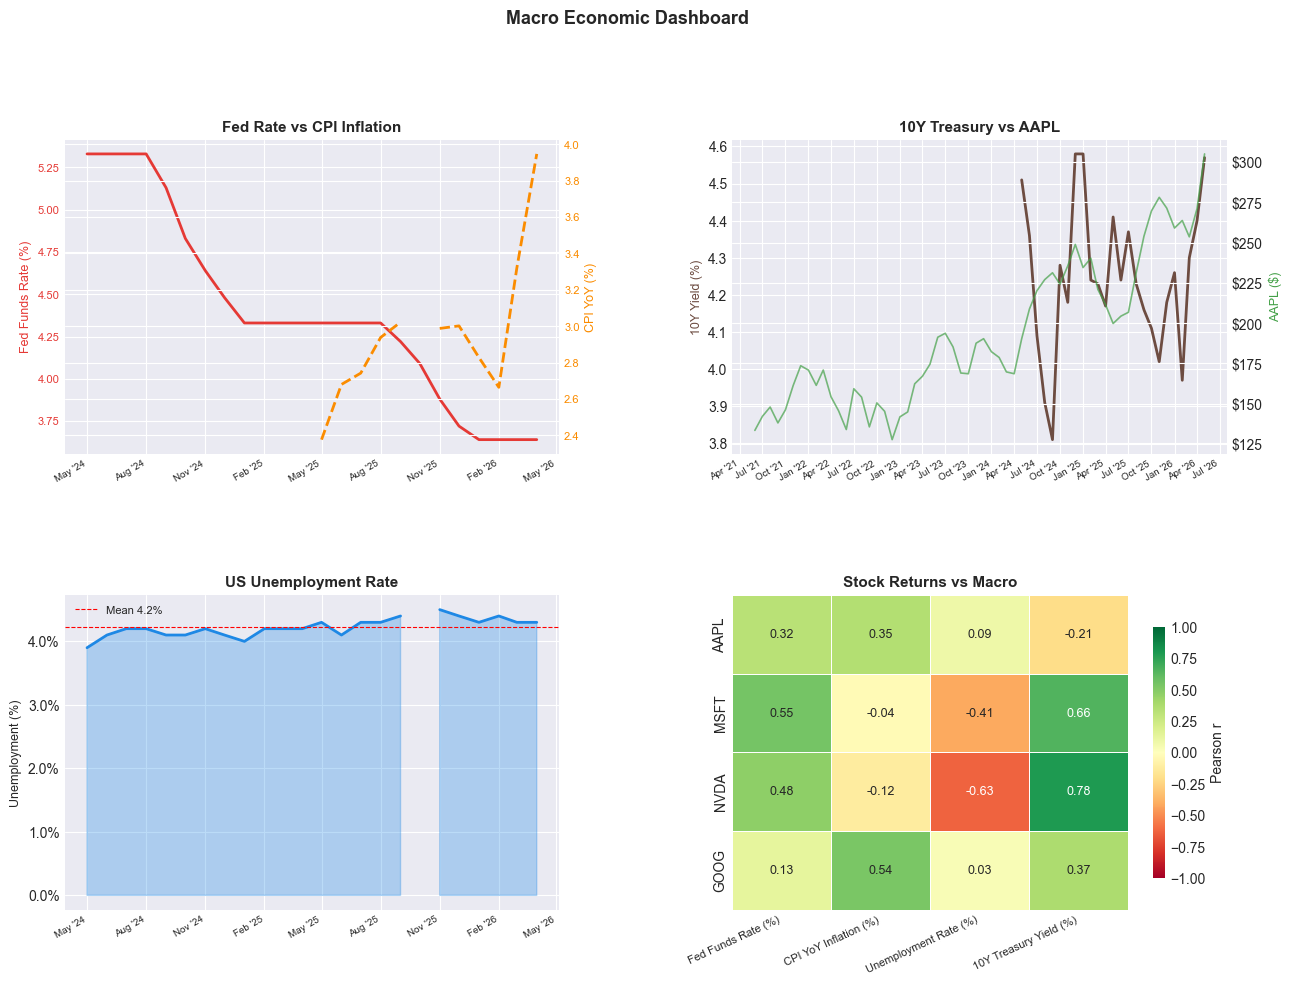

In [28]:
import matplotlib.gridspec as gridspec

if macro_df is None:
    print('⚠️  macro_fred.csv not found — chạy Module 2 trước')
else:
    ref_ticker = TICKERS[0]
    ref_price  = clean_dfs[ref_ticker]['Close'] if ref_ticker in clean_dfs else None

    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
    col_fed='#E53935'; col_cpi='#FB8C00'; col_unemp='#1E88E5'; col_tsy='#6D4C41'; col_stock='#43A047'

    ax1 = fig.add_subplot(gs[0,0])
    fed_col='Fed Funds Rate (%)'; cpi_col='CPI YoY Inflation (%)'
    if fed_col in macro_df.columns:
        ax1.plot(macro_df.index, macro_df[fed_col], color=col_fed, lw=2, label='Fed Funds Rate')
    if cpi_col in macro_df.columns:
        ax1_r = ax1.twinx()
        ax1_r.plot(macro_df.index, macro_df[cpi_col], color=col_cpi, lw=2, linestyle='--', label='CPI YoY')
        ax1_r.set_ylabel('CPI YoY (%)', color=col_cpi, fontsize=9)
        ax1_r.tick_params(axis='y', labelcolor=col_cpi, labelsize=8)
    ax1.set_ylabel('Fed Funds Rate (%)', color=col_fed, fontsize=9)
    ax1.tick_params(axis='y', labelcolor=col_fed, labelsize=8)
    ax1.set_title('Fed Rate vs CPI Inflation', fontweight='bold', fontsize=11)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

    ax2 = fig.add_subplot(gs[0,1])
    tsy_col = '10Y Treasury Yield (%)'
    if tsy_col in macro_df.columns:
        ax2.plot(macro_df.index, macro_df[tsy_col], color=col_tsy, lw=2, label='10Y Treasury')
        ax2.set_ylabel('10Y Yield (%)', color=col_tsy, fontsize=9)
    if ref_price is not None:
        ax2_r = ax2.twinx()
        ax2_r.plot(ref_price.index, ref_price, color=col_stock, lw=1.2, alpha=0.7, label=f'{ref_ticker}')
        ax2_r.set_ylabel(f'{ref_ticker} ($)', color=col_stock, fontsize=9)
        ax2_r.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}'))
    ax2.set_title(f'10Y Treasury vs {ref_ticker}', fontweight='bold', fontsize=11)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

    ax3 = fig.add_subplot(gs[1,0])
    unemp_col = 'Unemployment Rate (%)'
    if unemp_col in macro_df.columns:
        ax3.fill_between(macro_df.index, macro_df[unemp_col], alpha=0.3, color=col_unemp)
        ax3.plot(macro_df.index, macro_df[unemp_col], color=col_unemp, lw=2)
        ax3.axhline(macro_df[unemp_col].mean(), color='red', linestyle='--', lw=0.8, label=f'Mean {macro_df[unemp_col].mean():.1f}%')
        ax3.set_ylabel('Unemployment (%)', fontsize=9); ax3.set_title('US Unemployment Rate', fontweight='bold', fontsize=11)
        ax3.legend(fontsize=8); ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.1f}%'))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

    ax4 = fig.add_subplot(gs[1,1])
    stock_monthly = pd.DataFrame({
        t: clean_dfs[t]['Daily_Return'].resample('MS').mean()*21*100 for t in TICKERS if t in clean_dfs
    })
    macro_cols = [c for c in macro_df.columns if c in ['Fed Funds Rate (%)','CPI YoY Inflation (%)','Unemployment Rate (%)','10Y Treasury Yield (%)']]
    combined = pd.concat([stock_monthly, macro_df[macro_cols]], axis=1).dropna()
    if len(combined) > 3:
        corr = combined.corr().loc[TICKERS, macro_cols]
        sns.heatmap(corr, ax=ax4, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, center=0,
                    linewidths=0.5, cbar_kws={'label':'Pearson r','shrink':0.8}, annot_kws={'size':9})
        ax4.set_title('Stock Returns vs Macro', fontweight='bold', fontsize=11)
        ax4.set_xticklabels(ax4.get_xticklabels(), rotation=25, ha='right', fontsize=8)

    fig.suptitle('Macro Economic Dashboard', fontsize=13, fontweight='bold', y=1.01)
    plt.savefig('outputs/charts/chart6_macro_dashboard.png', dpi=DPI, bbox_inches='tight')
    plt.show()